In [2]:
using JLD2
using Plots
using LaTeXStrings

In [9]:
dir = "../send2/"
files = readdir(dir)
files = filter(f -> endswith(f, ".jld2"), files)

# println(files)

data = Dict{Tuple{Int,Int,Int}, Any}()
for file in files
    path = joinpath(dir, file)
    params = match(r"optimal_decoder_2_L(\d+)_T(\d+)_.*_B(\d+)_samples(\d+)_", file).captures
    L = parse(Int, params[1])
    T = parse(Int, params[2])
    B = parse(Int, params[3])
    samples = parse(Int, params[4])
    data[(L, T, B)] = jldopen(path) do f
        Dict(k => f[k] for k in keys(f))
    end
end

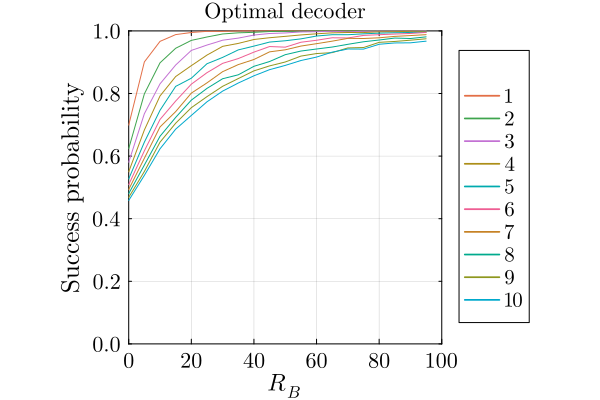

In [10]:
L = 200
plt = plot()

main_tickfont  = font("Computer Modern", 14)
inset_tickfont = font("Computer Modern", 10)

plot!([NaN], [NaN], color=:white, label=" ")
for t in 10:10:100
    prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:95]
    # push!(prob1s, 1.0)
    plot!(collect(0:5:95)/100, prob1s, label=L"%$(t ÷ 10)")
end
# for t in 1000:1000:10000
#     prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:45]
#     plot!(0:5:45, prob1s, label="T=$(t ÷ 10)")
# end

xticks = (0:0.2:1.0, 0:20:100)

plot!(plt, ylim=(0, 1), xlim=(0,1),
    xlabel=L"R_B", ylabel="Success probability", title="Optimal decoder",
    legend=:outerright,
    aspect_ratio=:equal,
    frame=:box,
    xticks=xticks,
    titlefont=main_tickfont,
    tickfont=main_tickfont,
    guidefont=main_tickfont,
    xguidefontsize=16,
    yguidefontsize=16,
    legendfontsize=14,)




plt

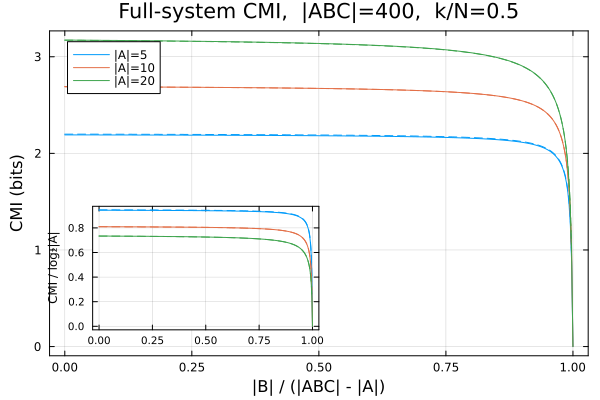

In [1]:
L = 200
plt = plot()

main_tickfont  = font("Computer Modern", 14)
inset_tickfont = font("Computer Modern", 10)

# ---- main plot ----
plot!(plt, [NaN], [NaN], color=:white, label=" ")  # dummy entry (your legend spacing)

for t in union(10:10:100, [1000,10000])
    prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:95]
    plot!(plt, collect(0:5:95) ./ 100, prob1s, label=L"%$(t ÷ 10)")
end

xticks = (0:0.2:1.0, 0:20:100)

plot!(plt;
    ylim=(0, 1), xlim=(0, 1),
    xlabel=L"R_B", ylabel="Success probability", title="Optimal decoder",
    legend=:outerright,
    aspect_ratio=:equal,
    frame=:box,
    xticks=xticks,
    titlefont=main_tickfont,
    tickfont=main_tickfont,
    guidefont=main_tickfont,
    xguidefontsize=16,
    yguidefontsize=16,
    legendfontsize=14,
)

# ---- inset (bottom-right), same plot again ----
BB = bbox(0.37, 0.08, 0.4, 0.4, :bottom, :left)  # (x, y, w, h) in figure fractions
plot!(plt;
    inset=(1, BB), subplot=2,
    frame=:box,
    grid=:false,
    legend=false,
    aspect_ratio=:equal,
    xlim=(-0.1, 1), ylim=(0, 1.1),
    xticks=xticks,
    tickfont=inset_tickfont,
    guidefont=inset_tickfont,
    xlabel="", ylabel="", title="",
        xguidefontsize=12,
    yguidefontsize=12,
    legendfontsize=10,
)

# re-draw the same curves into subplot=2
plot!(plt, [NaN], [NaN], subplot=2, color=:white, label=false)
for t in 10:10:100
    prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:95]
    plot!(plt, collect(0:5:95)/(t/10)/100, prob1s; subplot=2, label=false)
end

annotate!(plt, 1.17, 0.88, text(L"t", 14, "Computer Modern"), subplot=1)
annotate!(plt, 0.51, 0.15, text(L"R_B/t", 12, "Computer Modern"), subplot=2)

# savefig(plt, "optimal_decoder.pdf")

plt


In [17]:
data[(200, 10000, 0)]["prob1"]

0.17215365547987876

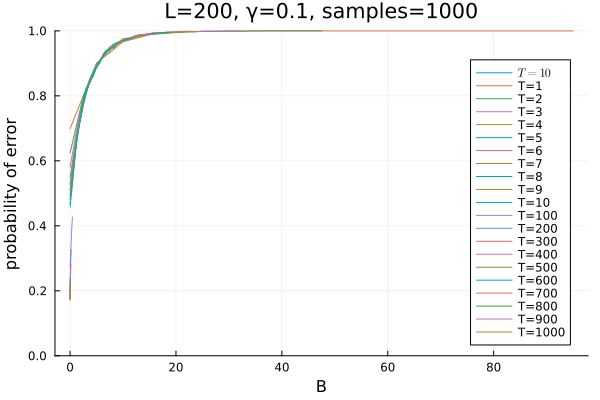

In [28]:
L = 200
plt = plot()
plot!([NaN], [NaN], label=L"T=10")
for t in 10:10:100
    prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:95]
    # push!(prob1s, 1.0)
    plot!(collect(0:5:95)/(t ÷ 10), prob1s, label="T=$(t ÷ 10)")
end
for t in 1000:1000:10000
    prob1s = [data[(L, t, B)]["prob1"] for B in 0:5:45]
    plot!(collect(0:5:45)/(t ÷ 10), prob1s, label="T=$(t ÷ 10)")
end
plot!(plt, ylim=(0, 1), xlabel="B", ylabel="probability of error", title="L=200, γ=0.1, samples=1000")
display(plt)

x		J		MC P(dw)	Std err
------------------------------------------------------------
0.05		1.4722		0.000015	0.000001
0.10		1.0986		0.000310	0.000004
0.15		0.8673		0.002146	0.000009
0.20		0.6931		0.009640	0.000020
0.25		0.5493		0.037484	0.000043
0.30		0.4236		0.184981	0.000102
0.35		0.3095		0.316355	0.000063
0.40		0.2027		0.391201	0.000055
0.45		0.1003		0.448996	0.000051
0.50		-0.0000		0.500072	0.000049


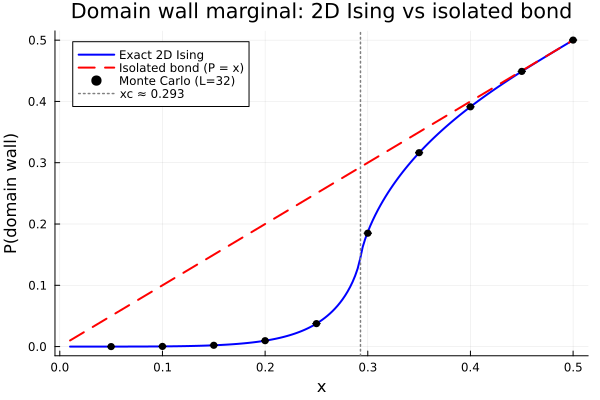

In [8]:
using Statistics
using Printf
using QuadGK
using Plots

# --- Parametrization ---
x_to_J(x) = -0.5 * log(x / (1 - x))
Jc = log(1 + sqrt(2)) / 2
xc = 1 / (1 + exp(2Jc))  # ≈ 0.293

# --- Analytical correlator via double integral ---
function correlator_analytical(J::Float64)
    result, _ = quadgk(0, π) do p1
        inner, _ = quadgk(0, π) do p2
            cosh(2J) * (2sinh(2J) - (cos(p1) + cos(p2))) /
            (cosh(2J)^2 - sinh(2J) * (cos(p1) + cos(p2)))
        end
        inner
    end
    return result / (2π^2)
end

p_dw_analytical(x) = (1 - correlator_analytical(x_to_J(x))) / 2

# --- Monte Carlo ---
function ising_mc(J::Float64, L::Int; n_warmup=20_000, n_samples=50_000)
    spins = rand([-1, 1], L, L)
    idx(i) = mod1(i, L)

    function energy_diff(s, i, j)
        neighbors = s[idx(i-1), j] + s[idx(i+1), j] +
                    s[i, idx(j-1)] + s[i, idx(j+1)]
        return 2J * s[i, j] * neighbors
    end

    function sweep!(s)
        for _ in 1:L*L
            i, j = rand(1:L), rand(1:L)
            ΔE = energy_diff(s, i, j)
            if ΔE <= 0 || rand() < exp(-ΔE)
                s[i, j] *= -1
            end
        end
    end

    for _ in 1:n_warmup; sweep!(spins) end

    samples = Float64[]
    for _ in 1:n_samples
        sweep!(spins)
        corr = sum(spins[i,j] * spins[idx(i+1),j] + spins[i,j] * spins[i,idx(j+1)]
                   for i in 1:L, j in 1:L)
        push!(samples, corr / (2L^2))
    end

    μ = mean(samples)
    σ = std(samples) / sqrt(length(samples))
    return (1 - μ)/2, σ/2  # convert to P(domain wall)
end

# --- Gather data ---
xs = collect(0.05:0.05:0.5)  # skip x=0 since J→∞

println("x\t\tJ\t\tMC P(dw)\tStd err")
println("-"^60)

mc_p = Float64[]
mc_err = Float64[]
for x in xs
    J = x_to_J(x)
    p, σ = ising_mc(J, 32)
    push!(mc_p, p)
    push!(mc_err, σ)
    @printf("%.2f\t\t%.4f\t\t%.6f\t%.6f\n", x, J, p, σ)
end

# --- Analytical curve ---
x_fine = range(0.01, 0.499, length=200)
p_exact = [p_dw_analytical(x) for x in x_fine]

# --- Plot ---
plot(x_fine, p_exact,
    label="Exact 2D Ising",
    lw=2, color=:blue)
plot!(x_fine, collect(x_fine),
    label="Isolated bond (P = x)",
    lw=2, color=:red, linestyle=:dash)
scatter!(xs, mc_p,
    yerr=mc_err,
    label="Monte Carlo (L=32)",
    color=:black, ms=4, markerstrokewidth=1)
vline!([xc],
    label=@sprintf("xc ≈ %.3f", xc),
    color=:gray, linestyle=:dot, lw=1.5)
xlabel!("x")
ylabel!("P(domain wall)")
title!("Domain wall marginal: 2D Ising vs isolated bond")